In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from define_variables import get_hmc_config
import arviz as az
from scipy.stats import norm
import imageio.v2 as imageio
from scipy.stats import gaussian_kde
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors
from matplotlib.colors import Normalize

In [2]:
config, config_str = get_hmc_config()

In [3]:
samples = np.load(f"../../../../output/2d_example_unified_temp/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/2d_example_unified_temp/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/2d_example_unified_temp/bias_values_{config_str}.npy")
delF = np.load(f"../../../../output/2d_example_unified_temp/delF_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/2d_example_unified_temp/resampsamp_{config_str}.npy")

(4, 100000, 7)


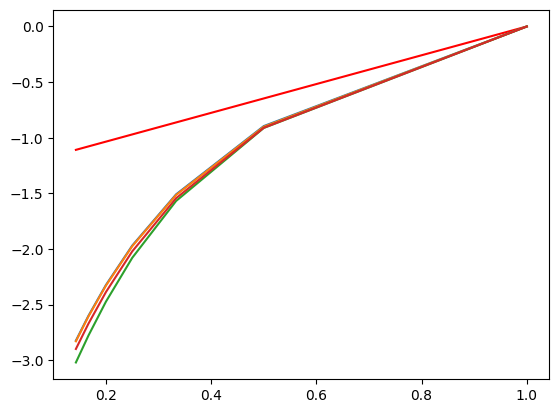

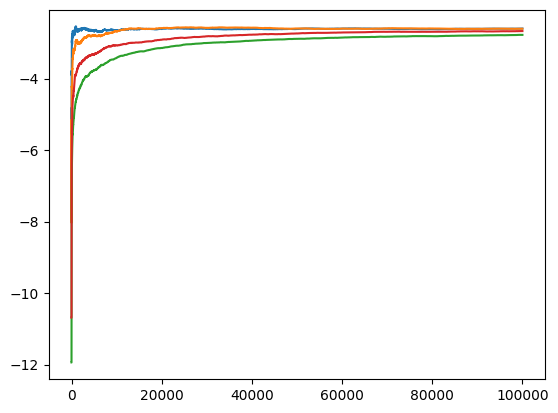

In [4]:
print(np.shape(delF))
temps = np.linspace(1, config["num_temps"], config["num_temps"])
plt.figure()
plt.plot(1/temps, 1.2937074351819173* (1/temps -1), color = "red")
for i in range(config["num_chains"]):
    plt.plot(1/temps, delF[i, -1, :])
plt.show()

plt.figure()
for i in range(config["num_chains"]):
    plt.plot(delF[i, :, 5])
plt.show()

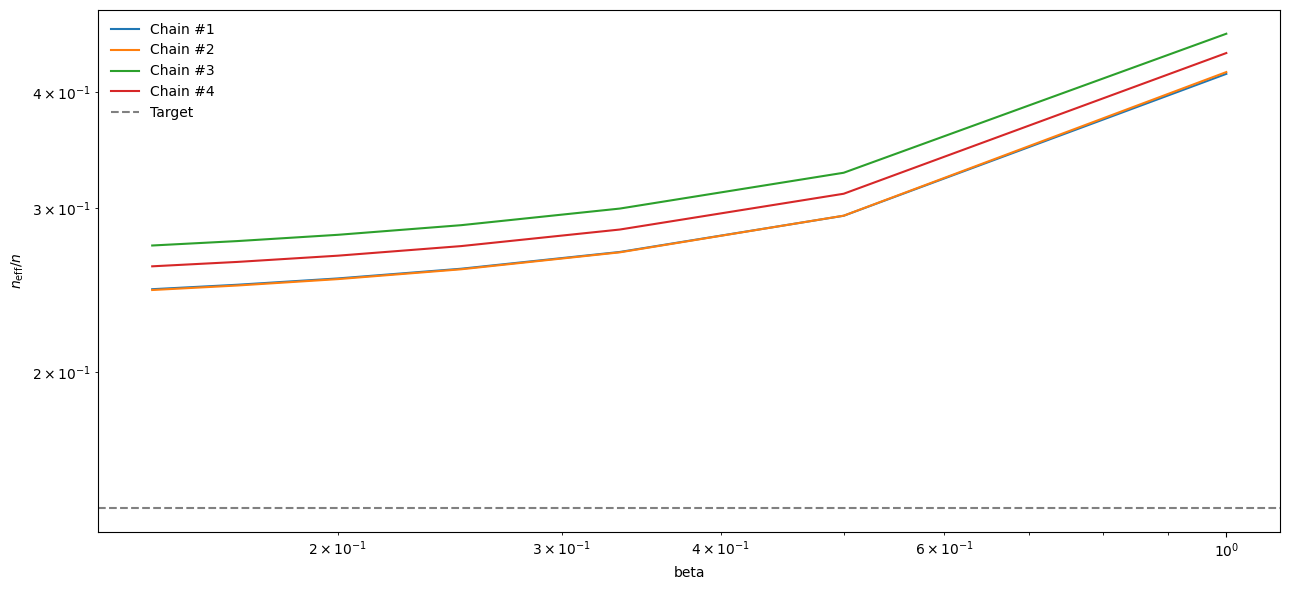

In [5]:
BETAS = 1 / temps
BETA_0= BETAS[0]
warmup = round(samples.shape[1] * 0.01)

delta_u = -(BETAS[None, None, :] - BETA_0) * energy_values[:, :, None]

weights = np.exp(-delta_u[:, warmup:, ] + bias_values[:, warmup:, None])

n_eff_lambda = np.sum(weights, axis=1)**2 / np.sum(weights**2, axis=1)
n_eff_lambda /= weights.shape[1]
target = 1 / config["num_temps"]

fig, ax = plt.subplots(
    1, 1,
    figsize=(13, 6),
)
for it in range(4):
    ax.plot(
        BETAS,
        n_eff_lambda[it],
        label=f'Chain #{it+1}',
    )

ax.axhline(target, color='grey', label='Target', ls='--')


ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_yscale('log')
ax.set_ylabel(r'$n_\text{eff} / n$')

ax.legend(frameon=False)

fig.tight_layout()

fig.savefig(
    f"../../../../pics/2d_example_unified_temp_pymc/neff_diag.jpg",
    bbox_inches='tight',
    pad_inches=0.05,
    dpi=300,
)

plt.show()


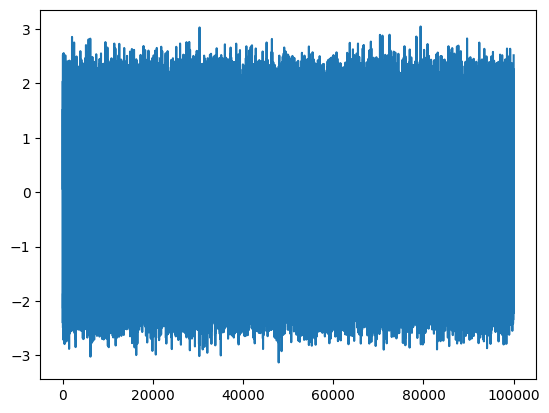

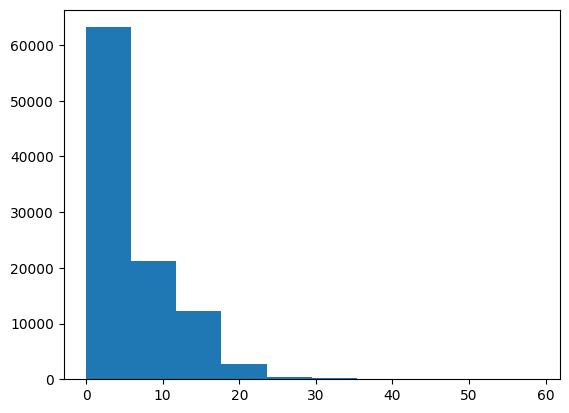

In [6]:
plt.figure()
# plt.plot(bias_values[0,:])
plt.plot(samples[0, :, 0])
# plt.plot(energy_values[0, :])
plt.show()

plt.figure()
plt.hist(energy_values[3,:])
plt.show()

In [7]:
def energy_function(variables):
    return 1.34549*variables[0]**4 + 1.90211*variables[0]**3*variables[1]+ 3.92705*variables[0]**2*variables[1]**2-6.44246*variables[0]**2- 1.90211*variables[0]*variables[1]**3+5.58721*variables[0]*variables[1] + 1.33481*variables[0] + 1.34549*variables[1]**4- 5.55754*variables[1]**2+0.904586*variables[1] + 18.5598

In [8]:
x = np.linspace(-3, 3, 1000)
y = np.linspace(-3, 3, 1000)
dx, dy = x[1]-x[0], y[1]-y[0]
X, Y = np.meshgrid(x, y, indexing="xy")

U = energy_function([X, Y])

P = np.exp(-U)
P/=np.sum(P)*dx*dy
true_marginal_likelihood = np.sum(P, axis = 0) * dy
free_energy = -np.log(true_marginal_likelihood)
free_energy-= np.min(free_energy)

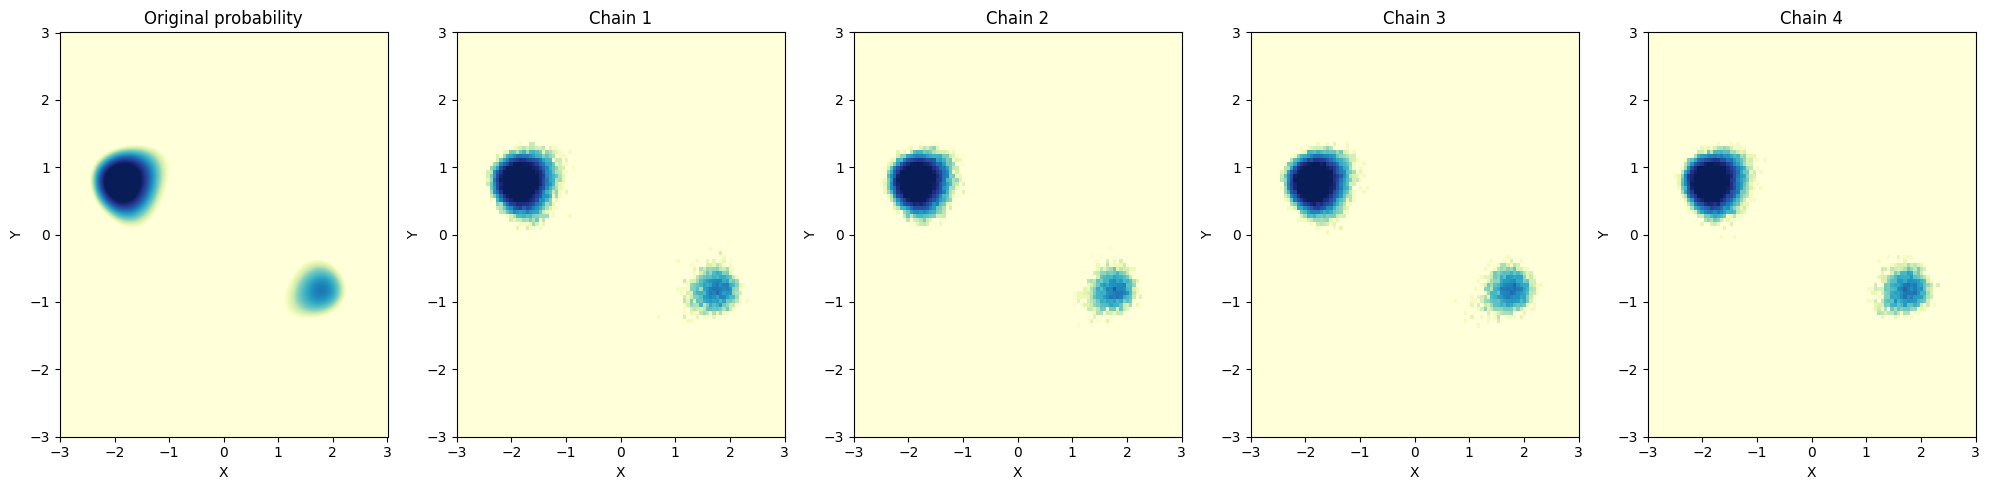

In [9]:
fig, axs= plt.subplots(1, config["num_chains"] + 1, figsize=(5*config["num_chains"], 5))
norm = colors.Normalize(vmin=P.min(), vmax=P.max())

axs[0].pcolormesh(X, Y, -np.log(P), cmap="YlGnBu_r", norm = norm, shading = "auto")
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_title(f"Original probability")

for i in range(1, config["num_chains"] + 1):
    # Compute a 2D histogram and normalize to get a probability density
    hist, xedges, yedges = np.histogram2d(
        resampled_samples[i-1, :, 0], resampled_samples[i-1, :, 1],
        bins=100, range=[[-3, 3], [-3, 3]], density=True
    )

    # Grid centers
    xpos = (xedges[:-1] + xedges[1:]) / 2
    ypos = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xpos, ypos, indexing='ij')

    # Plot as a 2D color map
    cmap = cm.YlGnBu_r
    norm = colors.Normalize(vmin=hist.min(), vmax=hist.max())
    pcm = axs[i].pcolormesh(X, Y, -np.log(hist + 1e-12), cmap=cmap, norm=norm, shading='auto')

    axs[i].set_xlabel("X")
    axs[i].set_ylabel("Y")
    axs[i].set_title(f"Chain {i}")

plt.tight_layout()
plt.show()

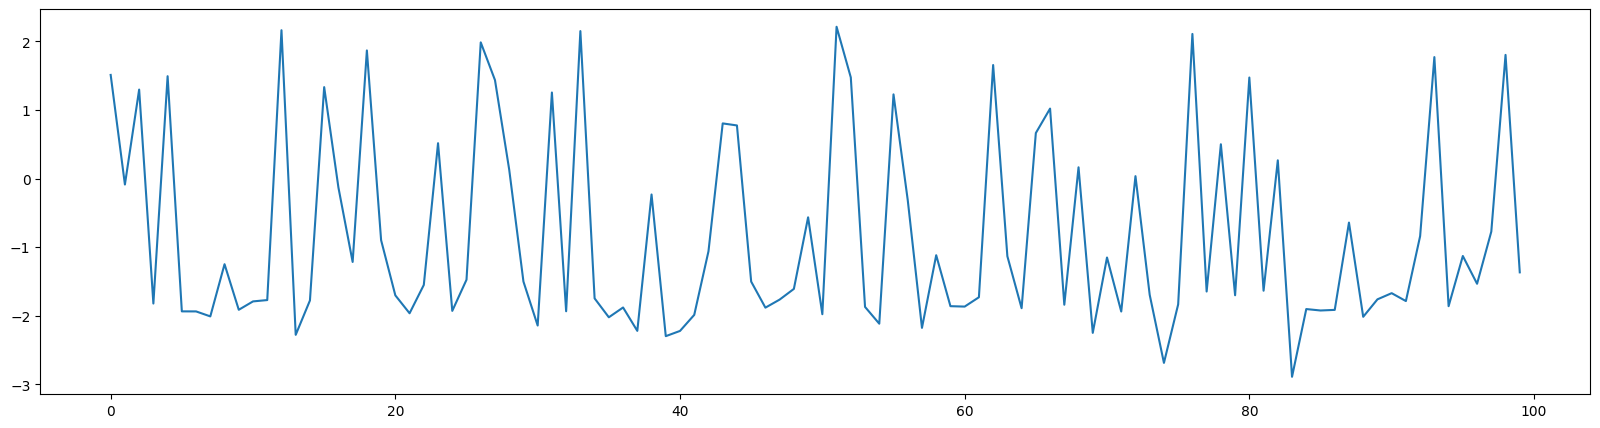

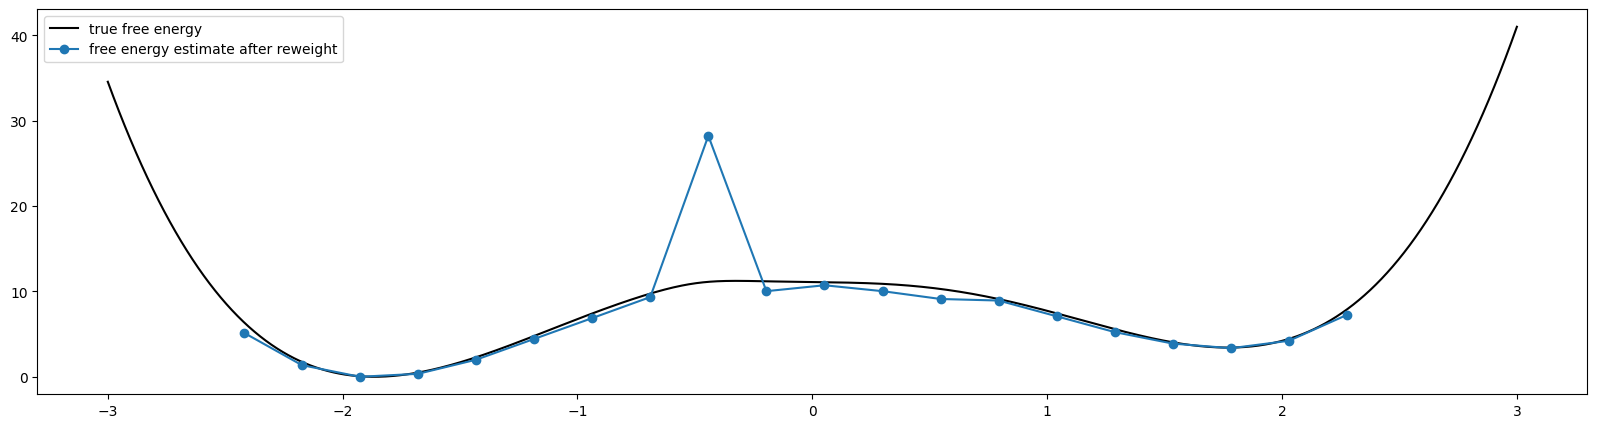

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
plt.plot(samples[0,::1000,0])
# plt.hist(samples[0,:,0], bins = 100)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
counts, bin_edges = np.histogram(resampled_samples[0,:, 0], bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
counts[counts == 0] = 1e-12  
free_energy_est_reweight = -np.log(counts)
free_energy_est_reweight-= np.min(free_energy_est_reweight)
ax.plot(x, free_energy, color="black", label=f"true free energy")
ax.plot(bin_centers, free_energy_est_reweight, '-o', label="free energy estimate after reweight")
# ax.plot(np.linspace(-3, 3, config["num_lambda"]), delF[0, -1, :] - np.min(delF[0, -1, :]))
plt.legend()
plt.show()

In [11]:
# import matplotlib.animation as animation
# from IPython.display import Image
# from IPython.display import HTML


# # Create the animation
# fig, ax = plt.subplots()
# x_vec = np.vstack((x, -np.ones_like(x)))
# energy_range = np.array([energy_function(x_vec[:, i]) for i in range(len(x_vec[0, :]))])
# line, = ax.plot(x, energy_range)
# ax.set_ylim(0, 40)
# ax.set_xlim(-3, 3)


# frames = 100
# E_lambdas = np.linspace(1, config["num_temps"], config["num_temps"])
# print(delF[0, :, 3])

# def update(frame):
#     # shape (1000, num_lambda)
#     factor = -((energy_range[:, None] - E_lambdas[None, :])**2) / (2 * config["sigma"]**2)

#     # get delF slice
#     delF_frame = delF[0, frame, :]

#     # stable log-sum-exp
#     log_terms = factor + delF_frame[None, :]
#     max_term = np.max(log_terms, axis=1)          # shape (1000,)
#     bias = - max_term - np.log(np.mean(np.exp(log_terms - max_term[:, None]), axis=1))
#     # print(frame)
#     # print(bias[0])
#     # print(bias[50])

#     # update free-energy estimate
#     to_plot = energy_range + bias
#     line.set_ydata(to_plot - np.min(to_plot))

#     return line,

# ani = animation.FuncAnimation(fig, update, frames=frames, blit=False)

# HTML(ani.to_jshtml())
# # ani.save("sinewave.gif", writer="pillow", fps=30)
# # plt.close(fig)

# # # Display it in the notebook
# # display(Image(filename="sinewave.gif"))


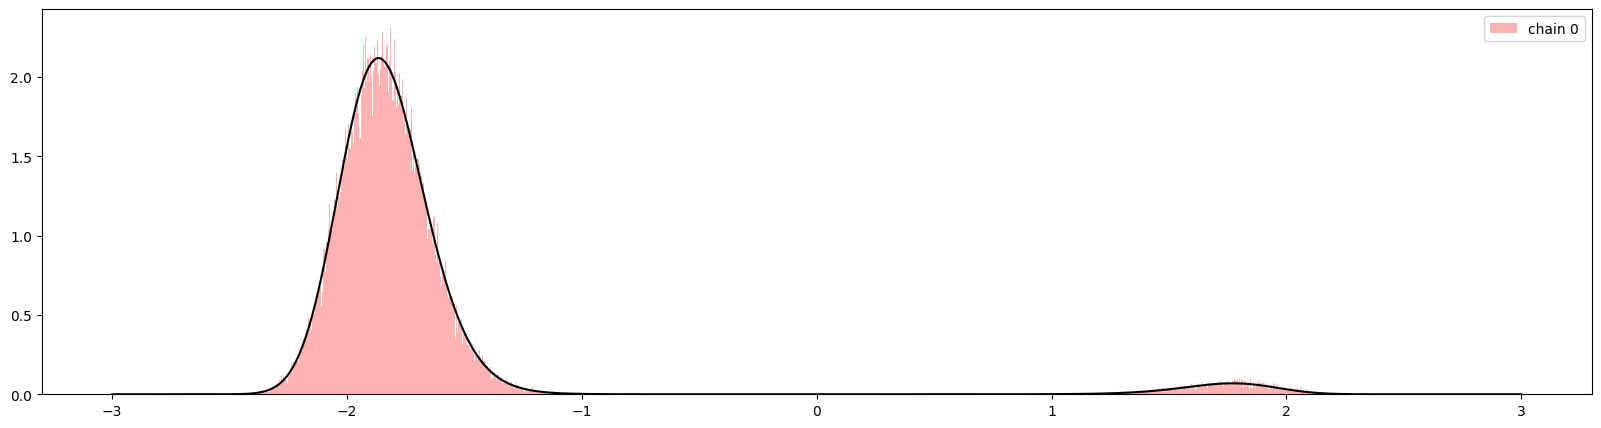

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5*config["num_chains"], 5))
ax.hist(resampled_samples[1, :, 0], bins=1000, color="red", density=True, alpha=0.3, label=f"chain {0}")
ax.legend()
ax.plot(x, true_marginal_likelihood, color="black")
plt.show()